<a href="https://colab.research.google.com/github/debasish-dash-create/DataAnalytics/blob/Projects/amazon_proj.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

In [2]:
am = pd.read_csv("amazon.csv")
am.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1465 entries, 0 to 1464
Data columns (total 16 columns):
 #   Column               Non-Null Count  Dtype 
---  ------               --------------  ----- 
 0   product_id           1465 non-null   object
 1   product_name         1465 non-null   object
 2   category             1465 non-null   object
 3   discounted_price     1465 non-null   object
 4   actual_price         1465 non-null   object
 5   discount_percentage  1465 non-null   object
 6   rating               1465 non-null   object
 7   rating_count         1463 non-null   object
 8   about_product        1465 non-null   object
 9   user_id              1465 non-null   object
 10  user_name            1465 non-null   object
 11  review_id            1465 non-null   object
 12  review_title         1465 non-null   object
 13  review_content       1465 non-null   object
 14  img_link             1465 non-null   object
 15  product_link         1465 non-null   object
dtypes: obj

# Duplicates checking in the data.


In [3]:
am.duplicated().value_counts()


,count
False,1465


# removing the ₹ symbol and removing ',' to convert the 'discounted price' column to float.

In [4]:
am['discounted_price'] = am['discounted_price'].str.strip('₹')
am['discounted_price'] = am['discounted_price'].str.replace(',','')
am['discounted_price'] = am['discounted_price'].astype(float)


# removing the ₹ symbol and removing ',' to convert the 'actual price' column to float.


In [5]:
am['actual_price'] = am['actual_price'].str.strip('₹')
am['actual_price'] = am['actual_price'].str.replace(',','')
am['actual_price'] = am['actual_price'].astype(float)


# removing faulty value row and resetting the index and dropping the new index column and converting the 'rating' column into float


In [6]:
am['rating'].value_counts()
am = am[am['rating'] != '|']

am['rating'] = am['rating'].astype(float)

am.reset_index(inplace=True)
am.drop('index',axis=1,inplace=True)

# removing unwanted columns



In [7]:
am.drop('user_id',axis=1,inplace=True)
am.drop('review_id',axis=1,inplace=True)
am.columns

Index(['product_id', 'product_name', 'category', 'discounted_price',
       'actual_price', 'discount_percentage', 'rating', 'rating_count',
       'about_product', 'user_name', 'review_title', 'review_content',
       'img_link', 'product_link'],
      dtype='object')

# converting percentage into int values by string and typecasting

In [8]:
am['discount_percentage'] = am['discount_percentage'].str.strip('%')
am['discount_percentage'] = am['discount_percentage'].astype(int)

# checking if nan values are there in the column and converting the object dtype to float.

In [9]:

am['rating_count'] = am['rating_count'].str.replace(',','')
am['rating_count'] = am['rating_count'].astype(float)

# am['rating_count'].isna().sum()
am['rating_count']=am['rating_count'].fillna(0.0)


# feature engineering, created 2 more specific category columns.


In [10]:
c1=[]
c2=[]

for i in am['category'].values:
  l= i.split('|')
  c1.append(l[0])
  c2.append(l[1])
am['category1'] = pd.Series(c1)
am['category2'] = pd.Series(c2)

# top 5 orders quantities/sales based on category1

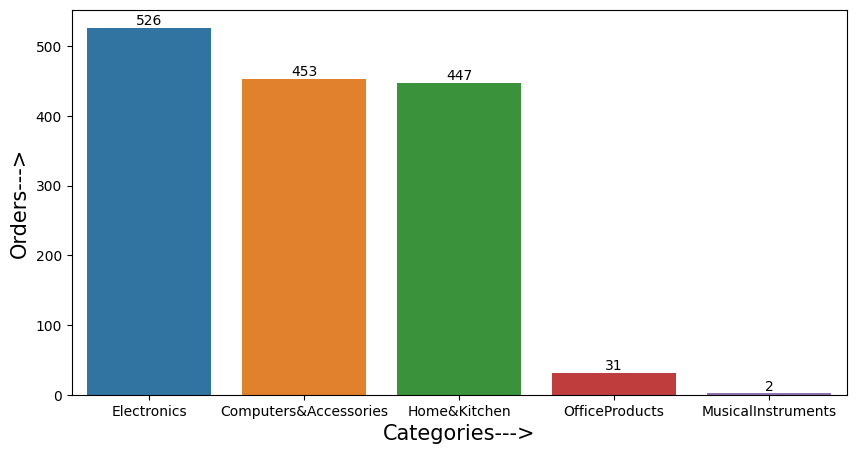

In [11]:
plt.figure(figsize=(10,5))

cop=am.groupby('category1').size().reset_index(name='orders').sort_values(by='orders',ascending=False).head()
cg1_bp = sns.barplot(x='category1',y='orders',data=cop,hue='category1')
plt.xlabel('Categories--->',fontsize=15)
plt.ylabel('Orders--->',fontsize=15)
for i in cg1_bp.containers:
  cg1_bp.bar_label(i)
plt.show()

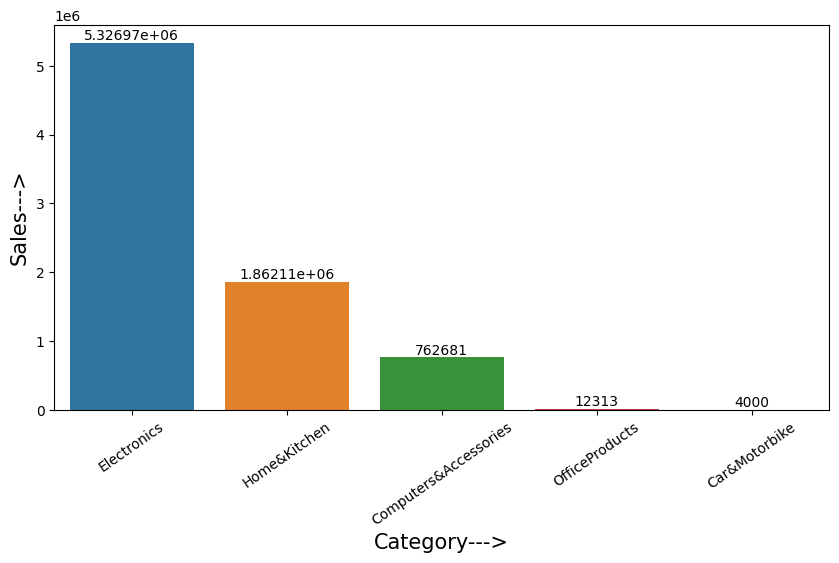

In [12]:
# sales based on category1

plt.figure(figsize=(10,5))

sales = pd.DataFrame(am.groupby('category1')['actual_price'].sum())
s_op=sales.sort_values(by='actual_price',ascending=False).head()

s_bp = sns.barplot(x='category1',y='actual_price',data=s_op,hue='category1')

for i in s_bp.containers:
  s_bp.bar_label(i)
plt.xticks(rotation=35)
plt.xlabel('Category--->',fontsize=15)
plt.ylabel('Sales--->',fontsize=15)

plt.show()

# top 5 orders quantities/sales based on category2


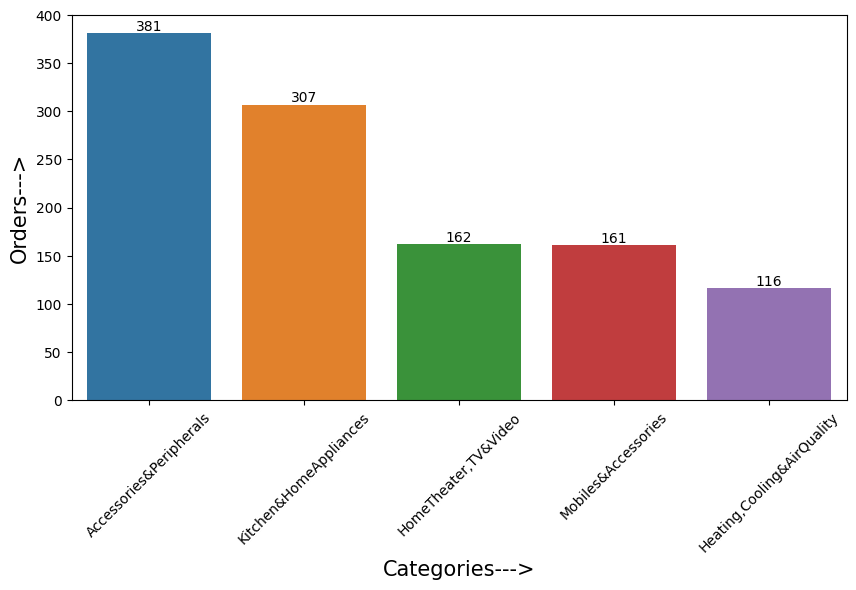

In [13]:
plt.figure(figsize=(10,5))

c2op=am.groupby('category2').size().reset_index(name='orders').sort_values(by='orders',ascending=False).head()
# .reset_index()
cg2_bp = sns.barplot(x='category2',y='orders',data=c2op,hue='category2')
plt.xlabel('Categories--->',fontsize=15)
plt.ylabel('Orders--->',fontsize=15)
plt.xticks(rotation=45)
for i in cg2_bp.containers:
  cg2_bp.bar_label(i)
plt.show()

# comparing the discount and sales of the category



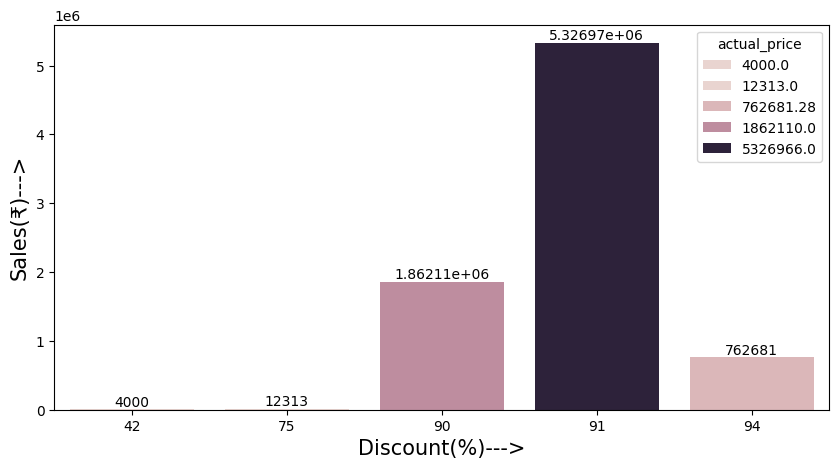

In [14]:
d_p= pd.DataFrame(am.groupby('category1')['discount_percentage'].max())

s_d = d_p.merge(sales,on='category1')
s_d_op=s_d.sort_values(by='actual_price',ascending=False).head()

plt.figure(figsize=(10,5))

s_d_bp = sns.barplot(x='discount_percentage',y='actual_price',data=s_d_op,hue='actual_price')

for i in s_d_bp.containers:
  s_d_bp.bar_label(i)
# plt.xticks(rotation=35)
plt.xlabel('Discount(%)--->',fontsize=15)
plt.ylabel('Sales(₹)--->',fontsize=15)

plt.show()

# average rating per category

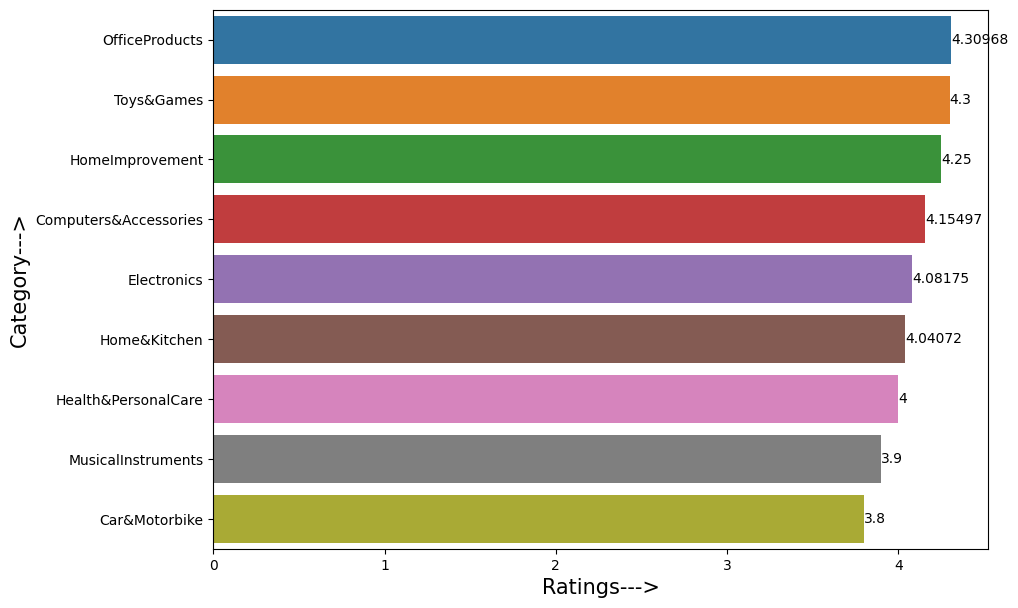

In [15]:
plt.figure(figsize=(10,7))
rat = pd.DataFrame(am.groupby('category1')['rating'].mean()).sort_values(by = 'rating',ascending = False).head(10)

rat_bp = sns.barplot(y='category1',x='rating',data=rat,hue='category1')

for i in rat_bp.containers:
  rat_bp.bar_label(i)
# plt.xticks(rotation=-90)
plt.ylabel('Category--->',fontsize=15)
plt.xlabel('Ratings--->',fontsize=15)

plt.show()


# Relation between the Price and Rating_count

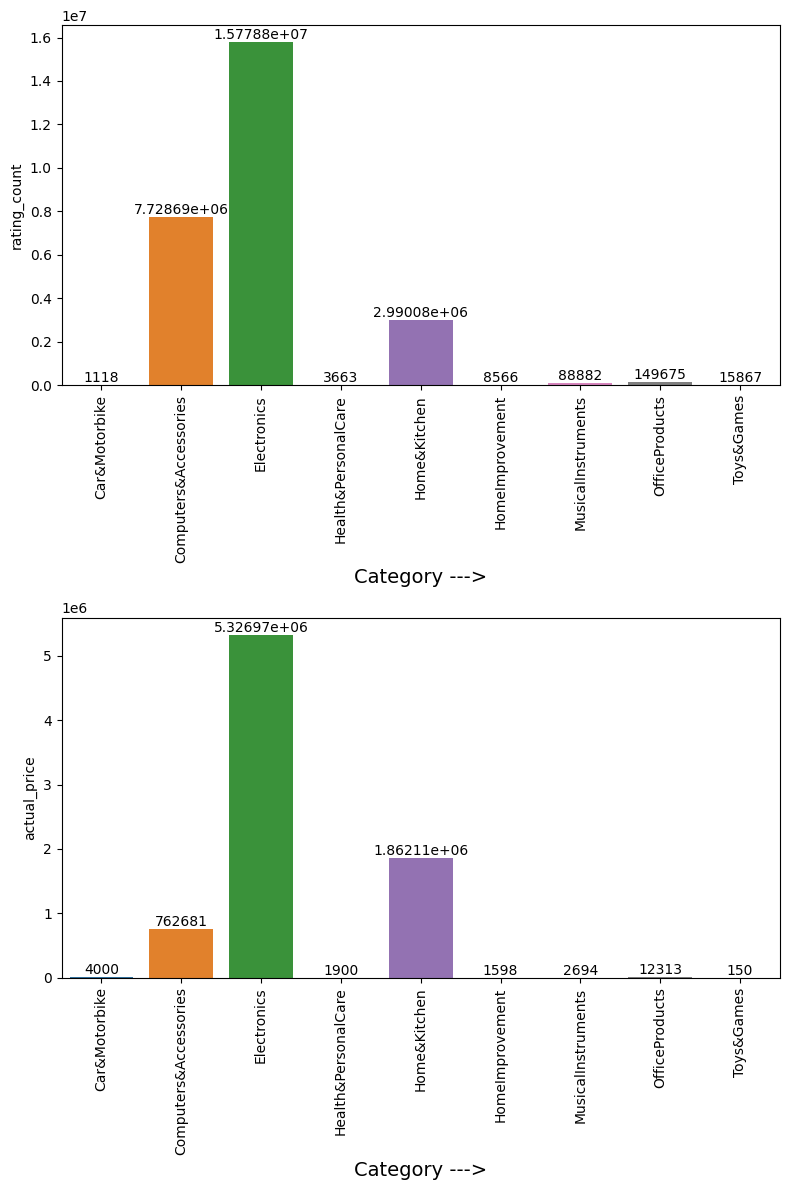

In [16]:
rc = pd.DataFrame(am.groupby('category1')['rating_count'].sum()).reset_index()
sc = pd.DataFrame(am.groupby('category1')['actual_price'].sum()).reset_index()

fig,axes = plt.subplots(2,1,figsize =(8,12))
axes[0].tick_params(axis='x', rotation=90)
axes[1].tick_params(axis='x', rotation=90)

axes[0].set_xlabel('Category --->', fontsize=14)
axes[1].set_xlabel('Category --->', fontsize=14)


rcvsc = sns.barplot(x='category1', y='rating_count', data=rc, hue='category1', ax=axes[0])
for i in rcvsc.containers:
  rcvsc.bar_label(i)

svsc = sns.barplot(x='category1', y='actual_price', data=sc, hue='category1', ax=axes[1])
for i in svsc.containers:
  svsc.bar_label(i)

plt.tight_layout()
plt.show()